In [11]:
import math

n = 5  # Total number of items
k = 3  # Number of items to choose

result = math.comb(n, k)
print(result)


10


Initialize two different types of Components (exponential and weibull)

ExponentialComponent(name=Pump A, state=0, distribution=Exponential)


Text(0.5, 1.0, 'Test Components State Histories')

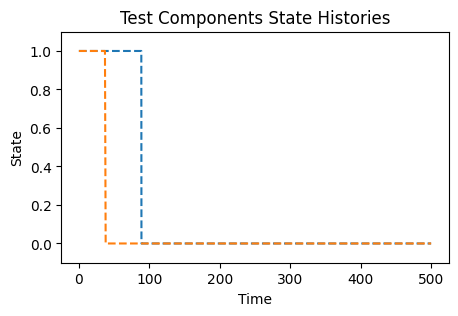

In [1]:
from component_objects.component_exponential import ExponentialComponent
from component_objects.component_weibull import WeibullComponent

# import logging
import matplotlib.pyplot as plt
import numpy as np

# set logging level here
# logging.basicConfig(level=logging.WARNING)

# simulate an exponential component
pump = ExponentialComponent(name="Pump A", MTTF=100, MTTR=10)
pump.simulate(t_end=500, dt=0.1)  # 500 time units, 1 per step
print(pump)

# simulate a weibull component
pump2 = WeibullComponent(name="Pump B", MTTF=100, MTTR=10, shape=1.5)
pump2.simulate(t_end=500, dt=1)  # 500 time units, 1 per step

# plot the histories of both components in a single plot
plt.figure(figsize=(5, 3))
pump.plot_history()
pump2.plot_history()
plt.title("Test Components State Histories")

Simulation 1000 comps of a specified distribution and plot histogram

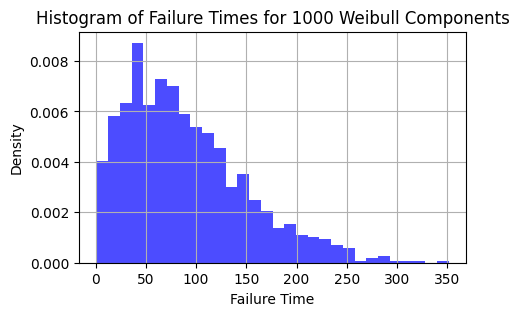

In [2]:
from component_objects.component_exponential import ExponentialComponent
from component_objects.component_weibull import WeibullComponent

import numpy as np
import matplotlib.pyplot as plt

# simulate 1000 exponential components and record their failure times
n = 1000

# distribution = "exponential"
distribution = "weibull"
failure_times = np.zeros(n)
for i in range(n):
    #initialize component
    if distribution == "exponential":
        pump = ExponentialComponent(name="Pump A", MTTF=100, MTTR=10)
    if distribution == "weibull":
        pump = WeibullComponent(name="Pump B", MTTF=100, MTTR=10, shape=1.5)
    failure_times[i] = pump.time_to_failure

# plot histogram of failure times
plt.figure(figsize=(5, 3))
plt.hist(failure_times, bins=30, density=True, alpha=0.7, color='blue')
plt.xlabel("Failure Time")
plt.ylabel("Density")
plt.title(f"Histogram of Failure Times for 1000 {distribution.capitalize()} Components")
plt.grid()